### Objective
0. Run after neur4.ipynb
1. Stimulus.  
a. Does population encode a stimulus axis? PCA & Regression.  
b. Does pairwise neural similarity track positional similarity? RSA and spearman.  
c. Same, but for on-manifold similarity.  
d. Is context-dependent stimulus class decodable? Decoding accuracy & chance.  

In [43]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection
from sklearn.decomposition import PCA


plot settings

In [44]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# %matplotlib widget
%matplotlib inline

variables & helpers (from neur4)

In [45]:
psychopy_df = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
# trials col first
psychopy_df = psychopy_df[['trial_key', *psychopy_df.columns.difference(['trial_key'], sort=False)]]
patients = psychopy_df['subj'].unique().tolist()
for patient in [9, 11]: patients.remove(patient)
conditions = ['curv_comp', 'baseline', 'flat_comp']

print(f'neural patients: {patients}')
print(f'conditions: {conditions}')

neural patients: [12, 18, 21, 22]
conditions: ['curv_comp', 'baseline', 'flat_comp']


In [46]:
def get_pt_metadata(psychopy_df, patient, verbose=True):
    pt_data_dir = f'../../results/2025{patient}/records/processed_data'
    pt_psychopy_df = psychopy_df.loc[psychopy_df['subj'] == patient].reset_index(drop=True)
    pt_neur_df     = pd.read_parquet(f'{pt_data_dir}/df_neurs.parquet')
    pt_num_neurs   = len(pt_neur_df)
    if verbose: print(f'patient={patient}', f'num_trials={len(pt_psychopy_df)}', f'num_neurons={pt_num_neurs}\n')
    return pt_psychopy_df, pt_neur_df, pt_num_neurs


def get_pt_epoch_spike_data(patient, epoch, verbose=True):
    pt_data_dir = f'../../results/2025{patient}/records/processed_data'
    pt_epoch_spikes     = np.load(f'{pt_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    pt_epoch_num_spikes = np.array([[len(pt_epoch_spikes[t, n]) for n in range(pt_epoch_spikes.shape[1])]
                                    for t in range(pt_epoch_spikes.shape[0])])
    pt_epoch_FRs  = np.load(f'{pt_data_dir}/{epoch}_FRs.npy', allow_pickle=True)
    pt_epoch_bins = np.load(f'{pt_data_dir}/{epoch}_bin_centers.npy', allow_pickle=True)
    if verbose:
        print(f'patient={patient}, epoch={epoch}')
        print(f'spikes (trials, neurons): {pt_epoch_spikes.shape}')
        print(f'FRs (trials, neurons, bins): {pt_epoch_FRs.shape}')
    return pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins


def get_contrast_in_epoch(psychopy_df, contrast, verbose=True):
    cont_trials, cont_labels = [], []
    if contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(psychopy_df[psychopy_df['condition'] == cond].index)
            cont_labels.append(cond)
    elif contrast == 'shape':
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'curv'].index)
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'flat'].index)
        cont_labels += ['curv', 'flat']
    elif contrast == 'valence':
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] > psychopy_df['div_pos_aligned']].index)
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] < psychopy_df['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    if verbose: print(f'contrast: {contrast}')
    return cont_trials, cont_labels


### a. Does population encode a stimulus axis? PCA & Regression.

In [47]:
epoch = 'stim'

# per patient, compute trial by neuron FR, by avging across bins
pt_data = {}
for patient in patients:
    pt_psychopy_df, _, pt_num_neurs = get_pt_metadata(psychopy_df, patient, verbose=False)
    _, _, pt_epoch_FRs, _ = get_pt_epoch_spike_data(patient, epoch, verbose=False)
    meanFRs = pt_epoch_FRs.mean(axis=2)        # (240, n_neurs)
    pt_data[patient] = {'psychopy': pt_psychopy_df, 'meanFRs': meanFRs, 'n_neurs': pt_num_neurs}

# per patient and condition,compute stim by neuron FR
cond_pt_means = {}
for cond in conditions:
    cond_pt_means[cond] = {}
    for patient in patients:
        pt_psychopy_df = pt_data[patient]['psychopy']
        cond_mask      = (pt_psychopy_df['condition'] == cond).values
        cond_stims     = pt_psychopy_df.loc[cond_mask, 'stim_pos'].round(2).values
        cond_meanFRs   = pt_data[patient]['meanFRs'][cond_mask]
        df_tmp = pd.DataFrame(cond_meanFRs)
        df_tmp['stim_pos'] = cond_stims
        cond_pt_means[cond][patient] = df_tmp.groupby('stim_pos').mean()  # (n_unique_pos, n_neurs)

# stack neurons across patients → PCA sees one shared population geometry
cond_matrices, cond_pos_values = {}, {}
for cond in conditions:
    all_stims = sorted(cond_pt_means[cond][patients[0]].index)
    FR_stimXneur = np.hstack([cond_pt_means[cond][pt].loc[all_stims].values for pt in patients])
    cond_matrices[cond]   = FR_stimXneur
    cond_pos_values[cond] = np.array(all_stims)
    print(f'{cond}: {len(all_stims)} unique stim_pos values, matrix {FR_stimXneur.shape}')

total_neurs = FR_stimXneur.shape[1]
print(f'\ntotal neurons across patients: {total_neurs}')

curv_comp: 15 unique stim_pos values, matrix (15, 57)
baseline: 20 unique stim_pos values, matrix (20, 57)
flat_comp: 15 unique stim_pos values, matrix (15, 57)

total neurons across patients: 57


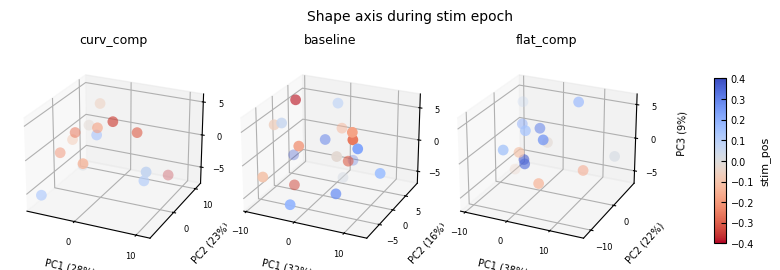

In [48]:
# does each boundary context have its own shape axis?
# fit PCA separately so each condition gets its own coordinate frame
view_elev, view_azim = 24, -65

fig = plt.figure(figsize=(8, 3))
for i, cond in enumerate(conditions, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    pca    = PCA(n_components=3)
    coords = pca.fit_transform(cond_matrices[cond])
    ev     = pca.explained_variance_ratio_
    sc     = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                        c=cond_pos_values[cond], cmap='coolwarm_r', vmin=-0.4, vmax=0.4,
                        s=60, linewidths=0)
    ax.set_title(cond, fontsize=9)
    ax.set_xlabel(f'PC1 ({ev[0]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.set_ylabel(f'PC2 ({ev[1]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.set_zlabel(f'PC3 ({ev[2]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.tick_params(labelsize=6, pad=0)
    ax.locator_params(nbins=3)
    ax.view_init(elev=view_elev, azim=view_azim)

cbar_ax = fig.add_axes([0.88, 0.2, 0.015, 0.55])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('stim_pos', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle(f'Shape axis during {epoch} epoch', fontsize=10)
plt.subplots_adjust(left=0.0, right=0.8, wspace=0.05)
plt.show()

condition     R² (LOO-CV)
curv_comp          -0.327
baseline           -0.674
flat_comp          -0.618


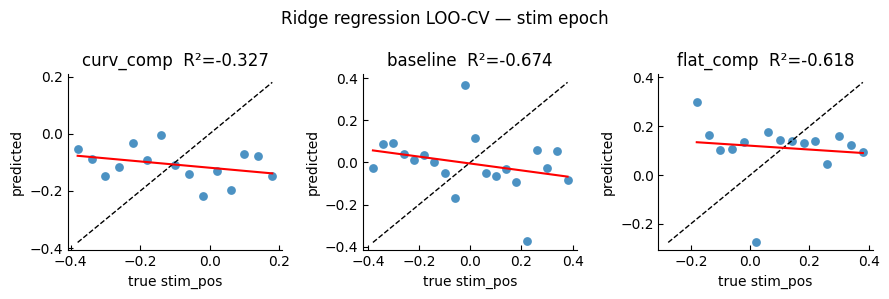

In [49]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

# does the population (original space) linearly encode stim_pos per condition?
# ridge regularization needed: 57 features >> 15-20 stim_pos samples
loo = LeaveOneOut()

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
print(f"{'condition':<12} {'R² (LOO-CV)':>12}")
for ax, cond in zip(axs, conditions):
    X, y = cond_matrices[cond], cond_pos_values[cond]
    y_pred = np.empty_like(y)
    for train, test in loo.split(X):
        y_pred[test] = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]).fit(X[train], y[train]).predict(X[test])
    r2 = r2_score(y, y_pred)
    print(f"{cond:<12} {r2:>12.3f}")

    ax.scatter(y, y_pred, s=40, alpha=0.8, linewidths=0)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='identity')
    m, b = np.polyfit(y, y_pred, 1)
    x_line = np.linspace(y.min(), y.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=1.5, label='best fit')
    ax.set(xlabel='true stim_pos', ylabel='predicted', title=f'{cond}  R²={r2:.3f}')

plt.suptitle(f'Ridge regression LOO-CV — {epoch} epoch')
plt.tight_layout()
plt.show()

### b. Does pairwise neural similarity track positional similarity? RSA and spearman.

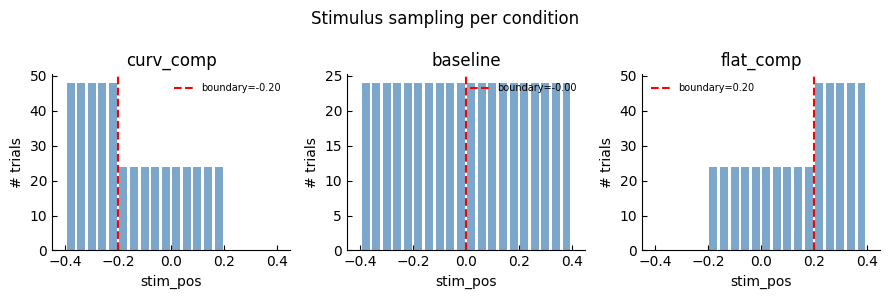

In [50]:
# what stim positions were sampled per condition, and where does the boundary fall?
# explains the asymmetric coverage in curv/flat that causes black rows/cols in the DSM

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for ax, cond in zip(axs, conditions):
    sub = psychopy_df[psychopy_df['condition'] == cond]
    stims    = sub['stim_pos'].round(2)
    pos_vals = sorted(stims.unique())
    counts   = stims.value_counts().sort_index()

    ax.bar(pos_vals, counts.values, width=0.03, color='steelblue', alpha=0.7)
    for div in sorted(sub['div_pos_aligned'].unique()):
        ax.axvline(div, color='r', linewidth=1.5, linestyle='--', label=f'boundary={div:.2f}')
    ax.set_xlim(-0.45, 0.45)
    ax.set_xlabel('stim_pos')
    ax.set_ylabel('# trials')
    ax.set_title(cond)
    ax.legend(fontsize=7, frameon=False)

plt.suptitle('Stimulus sampling per condition')
plt.tight_layout()
plt.show()

condition      r (Mantel)  p (permutation)
curv_comp           0.102            0.382
baseline           -0.030            0.667
flat_comp          -0.123            0.263


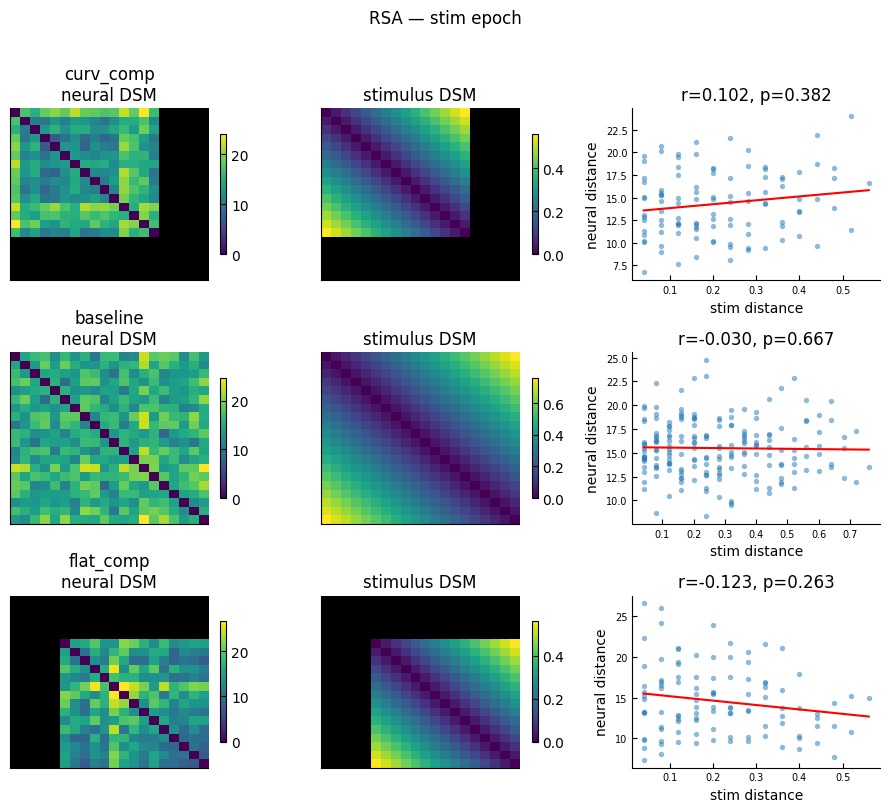

In [51]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# rows/cols = union of all sampled stim positions across conditions
# cells where a condition didn't sample that position are blacked out
n_perms = 1000
rng = np.random.default_rng(0)

all_stims_union = sorted(set().union(*[set(cond_pos_values[c]) for c in conditions]))
n_union = len(all_stims_union)
stim_to_idx = {s: i for i, s in enumerate(all_stims_union)}

cmap_dsm = plt.cm.viridis.copy()
cmap_dsm.set_bad('black')

fig, axs = plt.subplots(3, 3, figsize=(9, 8))
print(f"{'condition':<12} {'r (Mantel)':>12} {'p (permutation)':>16}")

for row, cond in enumerate(conditions):
    X, y = cond_matrices[cond], cond_pos_values[cond]
    sampled_idx = [stim_to_idx[s] for s in y]

    # full DSMs with NaN for unsampled positions → displayed as black
    D_neural_sq = squareform(pdist(X))
    D_stim_sq   = squareform(pdist(y.reshape(-1, 1)))
    D_neural_full = np.full((n_union, n_union), np.nan)
    D_stim_full   = np.full((n_union, n_union), np.nan)
    for i, si in enumerate(sampled_idx):
        for j, sj in enumerate(sampled_idx):
            D_neural_full[si, sj] = D_neural_sq[i, j]
            D_stim_full[si, sj]   = D_stim_sq[i, j]

    # Mantel test on sampled pairs only
    D_neural_vec = pdist(X)
    D_stim_vec   = pdist(y.reshape(-1, 1))
    r_obs, _ = spearmanr(D_neural_vec, D_stim_vec)
    r_perm = np.array([
        spearmanr(D_neural_vec, pdist(rng.permutation(y).reshape(-1, 1)))[0]
        for _ in range(n_perms)
    ])
    p = (np.abs(r_perm) >= np.abs(r_obs)).mean()
    print(f"{cond:<12} {r_obs:>12.3f} {p:>16.3f}")

    # neural DSM
    ax = axs[row, 0]
    im = ax.imshow(D_neural_full, cmap=cmap_dsm, aspect='auto', interpolation='none')
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set(title=f'{cond}\nneural DSM', xticks=[], yticks=[])

    # stimulus DSM (same mask)
    ax = axs[row, 1]
    im = ax.imshow(D_stim_full, cmap=cmap_dsm, aspect='auto', interpolation='none')
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set(title='stimulus DSM', xticks=[], yticks=[])

    # scatter with line of best fit
    ax = axs[row, 2]
    ax.scatter(D_stim_vec, D_neural_vec, s=15, alpha=0.5, linewidths=0)
    m, b = np.polyfit(D_stim_vec, D_neural_vec, 1)
    x_line = np.linspace(D_stim_vec.min(), D_stim_vec.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=1.5)
    ax.set(xlabel='stim distance', ylabel='neural distance', title=f'r={r_obs:.3f}, p={p:.3f}')
    ax.tick_params(labelsize=7)

plt.suptitle(f'RSA — {epoch} epoch', y=1.01)
plt.tight_layout()
plt.show()

### c. Same, but for on-manifold similarity.

### d. Is context-dependent stimulus class decodable? Decoding accuracy & chance.  

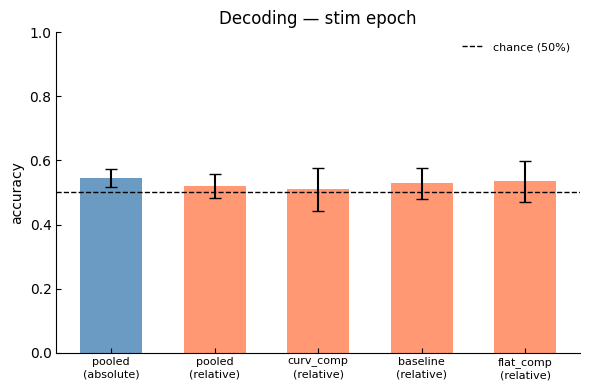

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

clf = LogisticRegression(penalty=None, max_iter=1000)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def decode_across_patients(get_y, cond_filter=None):
    accs = []
    for patient in patients:
        pt_psychopy_df = pt_data[patient]['psychopy']
        X = pt_data[patient]['meanFRs']
        y = get_y(pt_psychopy_df)
        if cond_filter is not None:
            mask = pt_psychopy_df['condition'] == cond_filter
            X, y = X[mask], y[mask]
        accs.append(cross_val_score(clf, X, y, cv=cv, scoring='accuracy').mean())
    return np.array(accs)

# absolute_class: is stim_pos above 0 regardless of boundary?
# relative_class: is stim_pos above the boundary? (stim_aligned_to_div > 0 is consistent across subjects)
absolute_class = lambda df: (df['stim_pos'] > 0).astype(int).values
relative_class = lambda df: (df['stim_aligned_to_div'] > 0).astype(int).values

# 5 bars: pooled-absolute, pooled-relative, then per-condition relative only
bar_specs = [
    ('pooled',     'absolute', absolute_class, None),
    ('pooled',     'relative', relative_class, None),
    ('curv_comp',  'relative', relative_class, 'curv_comp'),
    ('baseline',   'relative', relative_class, 'baseline'),
    ('flat_comp',  'relative', relative_class, 'flat_comp'),
]
labels    = [f'{scope}\n({target})' for scope, target, _, _ in bar_specs]
bar_data  = [decode_across_patients(get_y, cond) for _, _, get_y, cond in bar_specs]
colors    = ['steelblue', 'coral', 'coral', 'coral', 'coral']

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(bar_specs))
for i, (accs, color) in enumerate(zip(bar_data, colors)):
    ax.bar(x[i], accs.mean(), yerr=accs.std(), color=color, alpha=0.8, capsize=4, width=0.6)

ax.axhline(0.5, color='k', linestyle='--', linewidth=1, label='chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=8)
ax.set_title(f'Decoding — {epoch} epoch')
plt.tight_layout()
plt.show()

In [53]:
# # do conditions separate in a shared geometry?
# # fit one PC space so differences show up as displacement, not just a rotation of coordinates
# view_elev, view_azim = 24, -65

# X_all     = np.vstack([cond_matrices[c] for c in conditions])
# pca_joint = PCA(n_components=3).fit(X_all)
# ev_j      = pca_joint.explained_variance_ratio_

# markers = {'baseline': 'o', 'curv_comp': '^', 'flat_comp': 's'}
# fig = plt.figure(figsize=(6, 5))
# ax  = fig.add_subplot(111, projection='3d')
# for cond in conditions:
#     coords = pca_joint.transform(cond_matrices[cond])
#     sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
#                     c=cond_pos_values[cond], cmap='coolwarm', vmin=-0.4, vmax=0.4,
#                     s=60, marker=markers[cond], linewidths=0, label=cond)

# plt.colorbar(sc, ax=ax, label='stim_pos')
# ax.legend(title='condition', loc='best', frameon=False)
# ax.set(title=f'Representations separate by context?',
#        xlabel=f'PC1 ({ev_j[0]*100:.1f}%)', ylabel=f'PC2 ({ev_j[1]*100:.1f}%)',
#        zlabel=f'PC3 ({ev_j[2]*100:.1f}%)')
# ax.view_init(elev=view_elev, azim=view_azim)
# plt.tight_layout()
# plt.show()